In [49]:
import pandas as pd
import numpy as np
teams=pd.read_csv('dataset/teams.csv')
teams=teams[["team","country","year","athletes","age","prev_medals","medals"]]
teams

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3
2141,ZIM,Zimbabwe,2008,16,26.1,3.0,4
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


In [52]:
#finds correlation with columns 
teams.corr(numeric_only=True)["medals"]
#choosing features with maximum correlation

year          -0.034870
athletes       0.839909
age            0.023231
prev_medals    0.920048
medals         1.000000
Name: medals, dtype: float64

In [53]:


teams=teams.dropna()

In [54]:
X=teams[["athletes","prev_medals"]]
Y=teams["medals"]

In [55]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [56]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
lr.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
Y_lr_train_predict=lr.predict(X_train)
Y_lr_test_predict=lr.predict(X_test)

In [59]:
from sklearn.metrics import mean_squared_error,r2_score

In [60]:
mse_train=mean_squared_error(Y_train,Y_lr_train_predict)
mse_test=mean_squared_error(Y_test,Y_lr_test_predict)
r2_train=r2_score(Y_train,Y_lr_train_predict)
r2_test=r2_score(Y_test,Y_lr_test_predict)

print("MSE-train",mse_train)
print("MSE-test",mse_test)
print("R2-train",r2_train)
print("R2-test",r2_test)

MSE-train 152.02537758530204
MSE-test 113.88810801127025
R2-train 0.875965100619509
R2-test 0.8470082556938655


In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

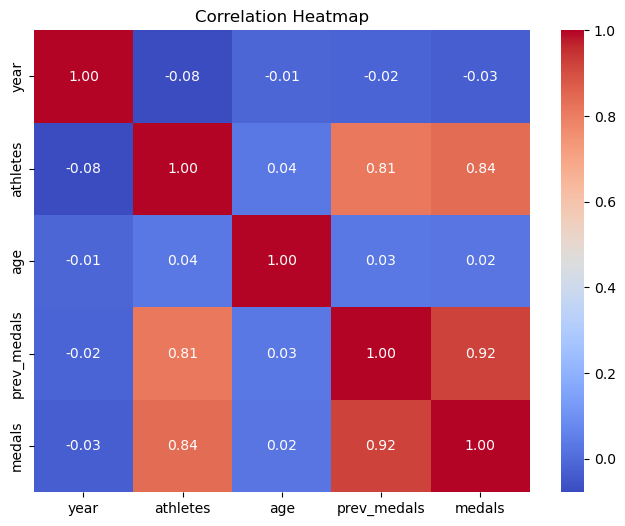

In [62]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    teams.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

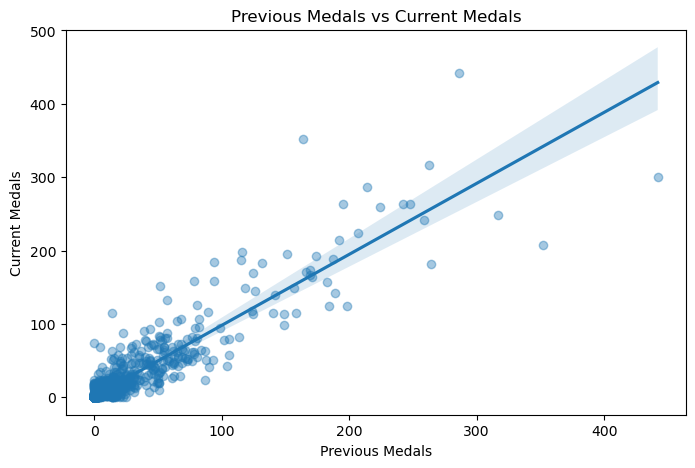

In [63]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=teams,
    x="prev_medals",
    y="medals",
    scatter_kws={"alpha": 0.4}
)

plt.title("Previous Medals vs Current Medals")
plt.xlabel("Previous Medals")
plt.ylabel("Current Medals")
plt.show()

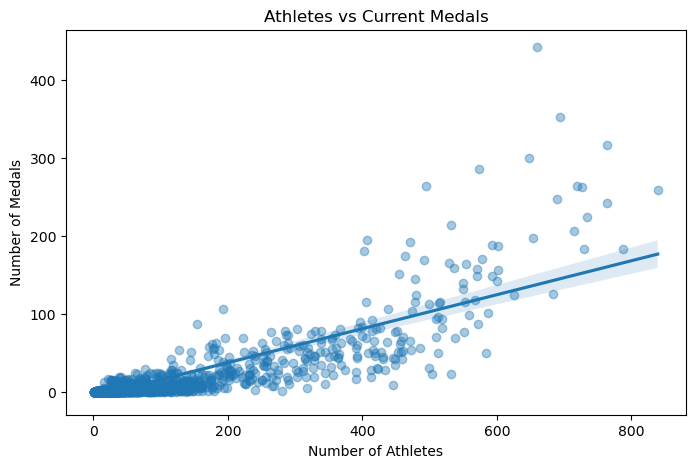

In [64]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=teams,
    x="athletes",
    y="medals",
    scatter_kws={"alpha": 0.4}
)

plt.title("Athletes vs Current Medals")
plt.xlabel("Number of Athletes")
plt.ylabel("Number of Medals")
plt.show()

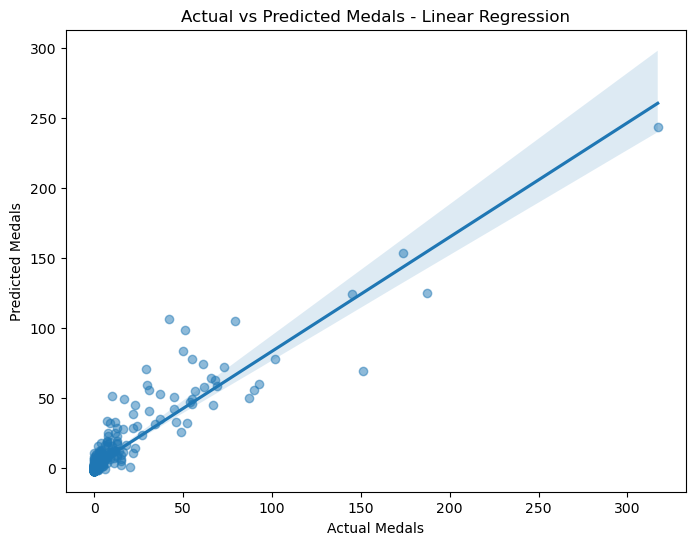

In [68]:

plt.figure(figsize=(8, 6))

sns.regplot(
    x=Y_test,
    y=Y_lr_test_predict.flatten(),
    scatter_kws={"alpha": 0.5}
)

plt.xlabel("Actual Medals")
plt.ylabel("Predicted Medals")
plt.title("Actual vs Predicted Medals - Linear Regression")
plt.show()